In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from multihist import Histdd
import numpy as np

### Update 11th June

In [2]:
pdf_xlzd = np.load('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/python_notebooks/ac_example_template.npz')

In [3]:
pdf_xlzd.files

['s1binedges', 's2binedges', 's1s2hist']

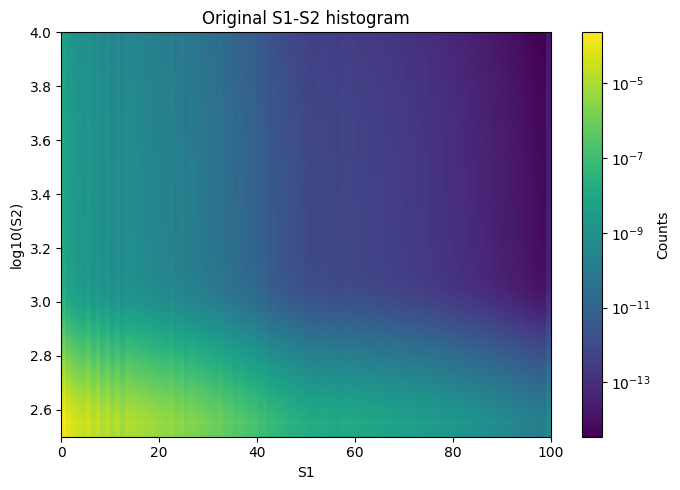

In [4]:
s1_edges = pdf_xlzd['s1binedges']
s2_edges = pdf_xlzd['s2binedges']


arr = pdf_xlzd['s1s2hist']

X, Y = np.meshgrid(s1_edges, s2_edges)

plt.figure(figsize=(7, 5))

pcm = plt.pcolormesh(
    X,
    Y,
    np.ma.masked_less_equal(arr.T, 0),   # transpose ONLY for plotting
    norm=LogNorm(
        vmin=arr[arr > 0].min(),
        vmax=arr.max()
    ),
    shading='auto'
)

plt.colorbar(pcm, label='Counts')
plt.xlabel('S1')
plt.ylabel('log10(S2)')
plt.title('Original S1-S2 histogram')
plt.tight_layout()
plt.show()

In [83]:
# import matplotlib.pyplot as plt
# from matplotlib.colors import LogNorm
# import numpy as np

# arr = pdf_xlzd['s1s2hist']

# plt.figure(figsize=(7, 5))
# plt.imshow(
#     np.ma.masked_less_equal(arr.T, 0),
#     origin='lower',
#     aspect='auto',
#     norm=LogNorm(
#         vmin=arr[arr > 0].min(),
#         vmax=arr.max()
#     )
# )

# plt.colorbar(label='Counts')
# plt.xlabel('S1 bin index')
# plt.ylabel('log10(S2) bin index')
# plt.title('Original S1-S2 histogram')
# plt.tight_layout()
# plt.show()

In [5]:
np.shape(pdf_xlzd['s1s2hist'])

(100, 100)

In [6]:
type(pdf_xlzd['s1s2hist'])

numpy.ndarray

In [7]:
print(pdf_xlzd['s1s2hist'])

[[1.37380071e-04 1.57025954e-04 1.70202192e-04 ... 5.36116625e-09
  5.16838945e-09 4.97465540e-09]
 [6.16112660e-05 7.04219161e-05 7.63311041e-05 ... 2.40433883e-09
  2.31788363e-09 2.23099911e-09]
 [3.73720430e-05 4.27163902e-05 4.63007741e-05 ... 1.45841922e-09
  1.40597739e-09 1.35327514e-09]
 ...
 [1.08280947e-10 1.23765543e-10 1.34150859e-10 ... 4.22559223e-15
  4.07364840e-15 3.92095007e-15]
 [9.66355767e-11 1.10454839e-10 1.19723238e-10 ... 3.77113935e-15
  3.63553674e-15 3.49926077e-15]
 [4.08205133e-10 4.66580050e-10 5.05731346e-10 ... 1.59299348e-14
  1.53571263e-14 1.47814734e-14]]


In [8]:
pdf_xlzd = np.load('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/python_notebooks/ac_example_template.npz')


cs1_bins = np.linspace(0, 100, 101)
log10cs2_bins = np.linspace(2.5, 4, 101)
rsq_bins = np.linspace(0, 21025, 51)


hist_1d_args = dict(
    bins = (rsq_bins,),
    axis_names = ['rsq'])


hist_args = dict(
                bins = (cs1_bins, log10cs2_bins, rsq_bins),
                axis_names = ['cS1', 'log10_cS2', 'rsq'])



# Producing a uniform rsq distribution
radius = 145. #cm
n_points = int(1e5)

data_R = (np.random.rand(n_points) * radius**2)**0.5                    #n_points is the length of the 
rsq = (data_R)**2

hist_1d = Histdd(**hist_1d_args)
hist_1d.add(rsq)
hist_1d = hist_1d / hist_1d.n

hist = Histdd(**hist_args)

hist.histogram = np.array([pdf_xlzd['s1s2hist'] * rsq_scaling for rsq_scaling in hist_1d.histogram])           #hist_2d.histogram is our histogram object
hist.histogram = np.transpose(hist.histogram, [1, 2, 0])

#Setting the rate of accidentals from the yaml paramters file
mu = 1 # accidental /ty

hist.histogram = mu * (hist.histogram / hist.n)


In [9]:
np.shape(hist.histogram)

(100, 100, 50)

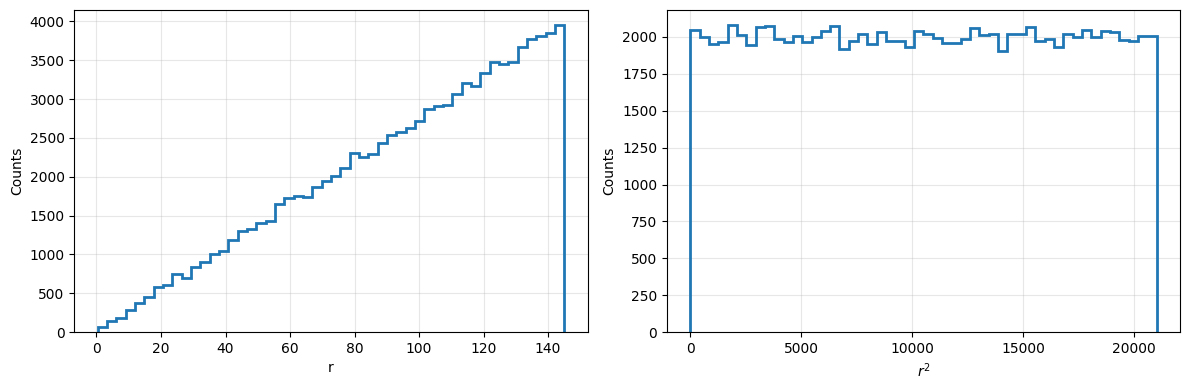

In [10]:
r = data_R
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# r distribution
ax[0].hist(r, bins=50, histtype='step', linewidth=2)
ax[0].set_xlabel('r')
ax[0].set_ylabel('Counts')
ax[0].grid(alpha=0.3)

# r² distribution
ax[1].hist(rsq, bins=50, histtype='step', linewidth=2)
ax[1].set_xlabel(r'$r^2$')
ax[1].set_ylabel('Counts')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

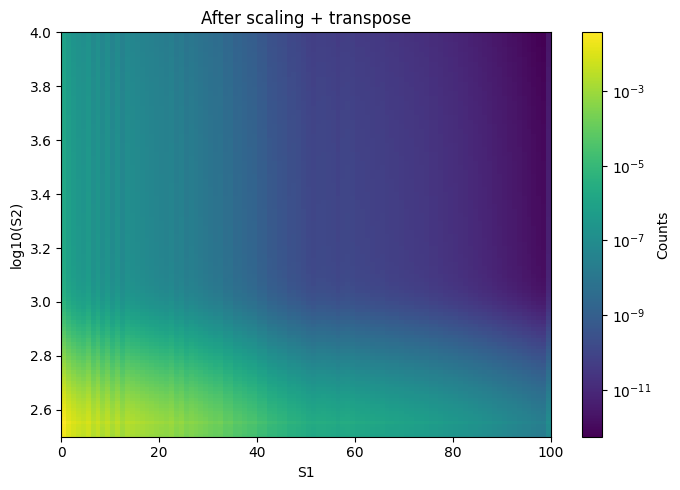

In [11]:
proj = hist.histogram.sum(axis=2)

X, Y = np.meshgrid(s1_edges, s2_edges)

plt.figure(figsize=(7, 5))

pcm = plt.pcolormesh(
    X,
    Y,
    np.ma.masked_less_equal(proj.T, 0),   # transpose ONLY for plotting
    norm=LogNorm(
        vmin=proj[proj > 0].min(),
        vmax=proj.max()
    ),
    shading='auto'
)

plt.colorbar(pcm, label='Counts')
plt.xlabel('S1')
plt.ylabel('log10(S2)')
plt.title('After scaling + transpose')
plt.tight_layout()
plt.show()

In [91]:
# import matplotlib.pyplot as plt
# from matplotlib.colors import LogNorm
# import numpy as np

# proj = hist.histogram.sum(axis=2)

# plt.figure(figsize=(7, 5))
# plt.imshow(
#     np.ma.masked_less_equal(proj.T, 0),
#     origin='lower',
#     aspect='auto',
#     norm=LogNorm(
#         vmin=proj[proj > 0].min(),
#         vmax=proj.max()
#     )
# )

# plt.colorbar(label='Counts')
# plt.xlabel('S1')
# plt.ylabel('S2')
# plt.title('After scaling + transposing')
# plt.tight_layout()
# plt.show()

for lz, the expected no. of accidentals is 1. I could scale this with exposure for now

In [92]:
pdf = np.load('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/python_notebooks/ac_template_lz_digitised.npz')

In [93]:
pdf.files

['s1binedges', 's2binedges', 's1s2hist']

In [94]:
np.shape(pdf['s1s2hist'])

(77, 55)

In [95]:
np.shape(pdf['s1binedges'])

(78,)

In [96]:
# print(pdf['s1binedges'])
# print(len(pdf['s1binedges']))
# print(pdf['s2binedges'])
# print(len(pdf['s2binedges']))
# print(pdf['s1s2hist'])
# print(np.shape(pdf['s1s2hist']))

In [97]:
pdf['s1s2hist']

array([[3.75570874e-04, 1.87371119e-03, 4.23718227e-03, ...,
        6.79858937e-04, 7.32208345e-04, 2.07474630e-04],
       [1.99677773e-04, 9.96186081e-04, 2.25276020e-03, ...,
        3.61456992e-04, 3.89289324e-04, 1.10306935e-04],
       [1.35807043e-04, 6.77537031e-04, 1.53217204e-03, ...,
        2.45838104e-04, 2.64767736e-04, 7.50231657e-05],
       ...,
       [6.77750891e-07, 3.38127772e-06, 7.64637052e-06, ...,
        1.22686564e-06, 1.32133478e-06, 3.74406337e-07],
       [8.48641827e-07, 4.23384718e-06, 9.57435826e-06, ...,
        1.53621266e-06, 1.65450164e-06, 4.68810712e-07],
       [4.32276301e-07, 2.15661277e-06, 4.87693163e-06, ...,
        7.82507182e-07, 8.42760546e-07, 2.38800109e-07]])

In [98]:
import numpy as np

s1_edges = pdf["s1binedges"]
s2_edges = pdf["s2binedges"]
hist = np.asarray(pdf["s1s2hist"])

# Flatten 2D histogram into probabilities
weights = hist.ravel()
prob = weights / weights.sum()

# Number of synthetic events to generate
N = 10000

# Choose histogram bins according to their weights
flat_idx = np.random.choice(len(weights), size=N, p=prob)
s1_bin_idx, s2_bin_idx = np.unravel_index(flat_idx, hist.shape)

# Sample uniformly inside each selected bin
s1_samples = np.random.uniform(
    s1_edges[s1_bin_idx],
    s1_edges[s1_bin_idx + 1]
)

s2_samples = np.random.uniform(
    s2_edges[s2_bin_idx],
    s2_edges[s2_bin_idx + 1]
)

# Combined S1/S2 event array
# samples = np.column_stack([s1_samples, s2_samples])

In [99]:
s1_samples

array([24.34935783,  4.47319097,  3.36411674, ...,  4.60789969,
        6.79264155,  6.46271382])

In [100]:
len(s1_samples)

10000

In [101]:
s2_samples

array([3.9395577 , 3.16233335, 3.48268106, ..., 3.54364488, 3.53537943,
       3.60034972])

In [102]:
s1c = s1_samples * 1.2
s2c = (10**s2_samples) * 1.2

print(np.max(s1c))
print(np.max(np.log10(s2c)))


95.64958551579096
4.565860777797646


In [103]:
radius = 145. #cm

data_R = (np.random.rand(N) * radius**2)**0.5

In [104]:
data_R

array([ 68.47982805,  62.3551938 ,  81.77800082, ...,  98.24455345,
       134.01044263, 117.72870462])

In [105]:
from multihist import Histdd


cS1 = s1c
log10_cS2 = np.log10(s2c)
rsq = (data_R)**2

cs1_bins = np.linspace(0, 100, 101)
log10cs2_bins = np.linspace(2.5, 4, 101)
rsq_bins = np.linspace(0, 21025, 51)


hist_1d_args = dict(
    bins = (rsq_bins,),
    axis_names = ['rsq'])

hist_2d_args = dict(
        bins = (cs1_bins, log10cs2_bins),
        axis_names = ['cS1', 'log10_cS2'])

hist_args = dict(
                bins = (cs1_bins, log10cs2_bins, rsq_bins),
                axis_names = ['cS1', 'log10_cS2', 'rsq'])


hist_2d = Histdd(**hist_2d_args)
hist_2d.add(cS1, log10_cS2)

print(hist_2d)
print(np.shape(hist_2d))
print(type(hist_2d))
print(hist_2d.histogram)
print(np.shape(hist_2d.histogram))
print(type(hist_2d.histogram))

hist_1d = Histdd(**hist_1d_args)
hist_1d.add(rsq)
hist_1d = hist_1d / hist_1d.n
# print(hist_1d)
# print(np.shape(hist_1d))

hist = Histdd(**hist_args)

hist.histogram = np.array([hist_2d.histogram * rsq_scaling for rsq_scaling in hist_1d.histogram])
hist.histogram = np.transpose(hist.histogram, [1, 2, 0])
# print(hist.histogram)
# print(np.shape(hist.histogram))

mu = 1 # accidental /ty

hist.histogram = mu * (hist.histogram / hist.n)

template = hist

(100, 100)
<class 'multihist.Histdd'>
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(100, 100)
<class 'numpy.ndarray'>


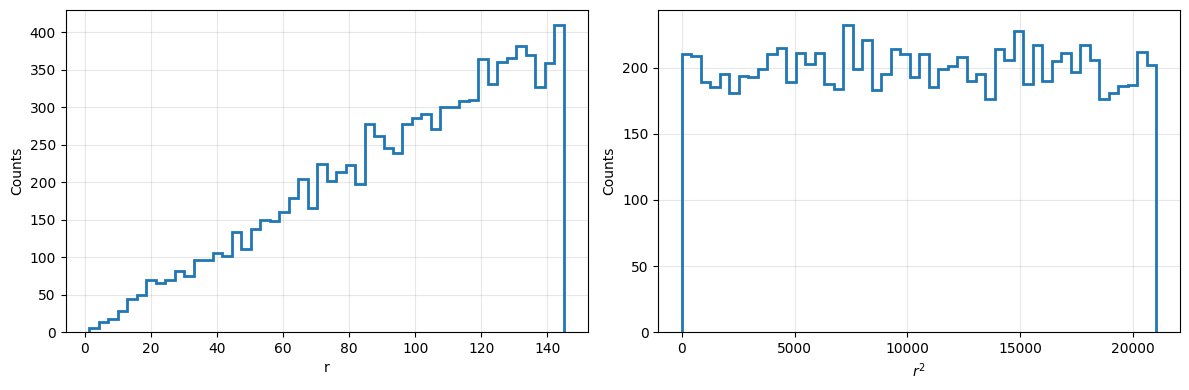

In [106]:
r = data_R
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# r distribution
ax[0].hist(r, bins=50, histtype='step', linewidth=2)
ax[0].set_xlabel('r')
ax[0].set_ylabel('Counts')
ax[0].grid(alpha=0.3)

# r² distribution
ax[1].hist(rsq, bins=50, histtype='step', linewidth=2)
ax[1].set_xlabel(r'$r^2$')
ax[1].set_ylabel('Counts')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

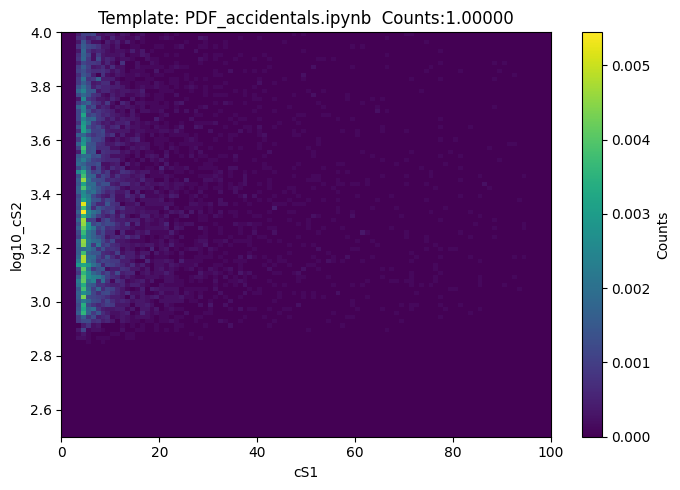

In [107]:
filename = 'PDF_accidentals.ipynb'

import numpy as np
arr = hist.histogram

if arr.ndim == 2:
    x_edges = hist.bin_edges[0]
    y_edges = hist.bin_edges[1]
    X, Y = np.meshgrid(x_edges, y_edges)
    plt.figure(figsize=(7,5))
    pcm = plt.pcolormesh(X, Y, arr.T, cmap='viridis')
    plt.colorbar(pcm, label='Counts')
    plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
    plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
    plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
    plt.tight_layout()
    plt.show()

elif arr.ndim == 1:
    # keep existing 1D behaviour
    hist.plot()
    plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
    plt.show()

else:
    # project all axes beyond the first two
    proj = arr.sum(axis=tuple(range(2, arr.ndim))) if arr.ndim > 2 else arr
    if len(hist.bin_edges) >= 2:
        x_edges = hist.bin_edges[0]
        y_edges = hist.bin_edges[1]
        X, Y = np.meshgrid(x_edges, y_edges)
        plt.figure(figsize=(7,5))
        pcm = plt.pcolormesh(X, Y, proj.T, cmap='viridis')
        plt.colorbar(pcm, label='Counts')
        plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
        plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
        plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
        plt.tight_layout()
        plt.show()
    else:
        hist.plot()
        plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
        plt.show()

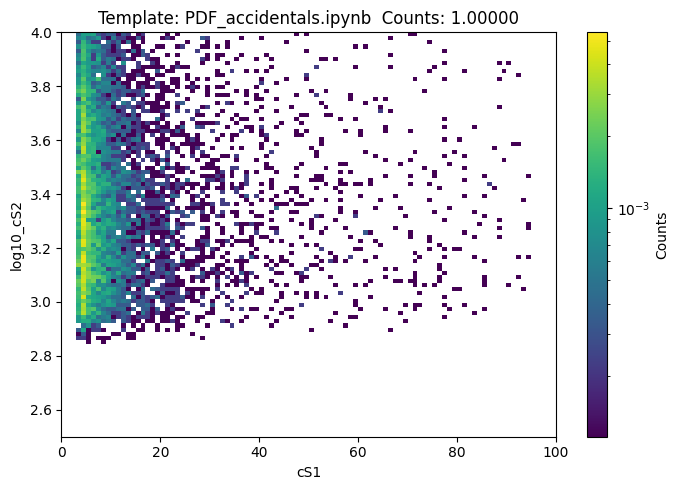

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

filename = 'PDF_accidentals.ipynb'

arr = hist.histogram
use_log = True

if arr.ndim == 2:
    x_edges = hist.bin_edges[0]
    y_edges = hist.bin_edges[1]
    X, Y = np.meshgrid(x_edges, y_edges)

    norm = None
    if use_log and np.any(arr > 0):
        norm = LogNorm(vmin=arr[arr > 0].min(), vmax=arr.max())

    plt.figure(figsize=(7, 5))
    pcm = plt.pcolormesh(
        X, Y, np.ma.masked_less_equal(arr.T, 0) if use_log else arr.T,
        cmap='viridis',
        norm=norm
    )
    plt.colorbar(pcm, label='Counts')
    plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
    plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
    plt.title(f"Template: {filename}  Counts: {hist.n:.5f}")
    plt.tight_layout()
    plt.show()

elif arr.ndim == 1:
    hist.plot()
    plt.title(f"Template: {filename}  Counts: {hist.n:.5f}")
    plt.show()

else:
    # Project all axes beyond the first two
    proj = arr.sum(axis=tuple(range(2, arr.ndim)))

    if len(hist.bin_edges) >= 2:
        x_edges = hist.bin_edges[0]
        y_edges = hist.bin_edges[1]
        X, Y = np.meshgrid(x_edges, y_edges)

        norm = None
        if use_log and np.any(proj > 0):
            norm = LogNorm(vmin=proj[proj > 0].min(), vmax=proj.max())

        plt.figure(figsize=(7, 5))
        pcm = plt.pcolormesh(
            X, Y, np.ma.masked_less_equal(proj.T, 0) if use_log else proj.T,
            cmap='viridis',
            norm=norm
        )
        plt.colorbar(pcm, label='Counts')
        plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
        plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
        plt.title(f"Template: {filename}  Counts: {hist.n:.5f}")
        plt.tight_layout()
        plt.show()
    else:
        hist.plot()
        plt.title(f"Template: {filename}  Counts: {hist.n:.5f}")
        plt.show()

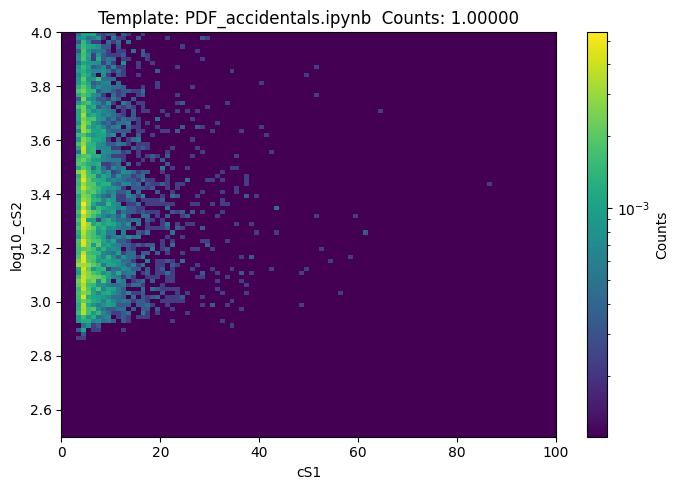

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from copy import copy

filename = 'PDF_accidentals.ipynb'

arr = hist.histogram
use_log = True

# Copy viridis and force masked values to use the darkest colour
cmap = copy(plt.cm.viridis)
cmap.set_bad(cmap(0))

if arr.ndim == 2:

    x_edges = hist.bin_edges[0]
    y_edges = hist.bin_edges[1]
    X, Y = np.meshgrid(x_edges, y_edges)

    arr_plot = np.ma.masked_less_equal(arr.T, 0)

    norm = None
    if np.any(arr > 0):
        norm = LogNorm(
            vmin=arr[arr > 0].min(),
            vmax=arr.max()
        )

    plt.figure(figsize=(7, 5))

    pcm = plt.pcolormesh(
        X,
        Y,
        arr_plot,
        cmap=cmap,
        norm=norm,
        shading='auto'
    )

    plt.colorbar(pcm, label='Counts')
    plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
    plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
    plt.title(f"Template: {filename}  Counts: {hist.n:.5f}")
    plt.tight_layout()
    plt.show()

elif arr.ndim == 1:

    hist.plot()
    plt.yscale('log')
    plt.title(f"Template: {filename}  Counts: {hist.n:.5f}")
    plt.tight_layout()
    plt.show()

else:

    # Project higher dimensions onto first two axes
    proj = arr.sum(axis=tuple(range(2, arr.ndim)))

    x_edges = hist.bin_edges[0]
    y_edges = hist.bin_edges[1]
    X, Y = np.meshgrid(x_edges, y_edges)

    proj_plot = np.ma.masked_less_equal(proj.T, 0)

    norm = None
    if np.any(proj > 0):
        norm = LogNorm(
            vmin=proj[proj > 0].min(),
            vmax=proj.max()
        )

    plt.figure(figsize=(7, 5))

    pcm = plt.pcolormesh(
        X,
        Y,
        proj_plot,
        cmap=cmap,
        norm=norm,
        shading='auto'
    )

    plt.colorbar(pcm, label='Counts')
    plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
    plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
    plt.title(f"Template: {filename}  Counts: {hist.n:.5f}")
    plt.tight_layout()
    plt.show()